# Real-Time AI Invoice (`ainvoices`) Validation & Matching Engine
## High-Throughput Streaming Validation, Sub-Millisecond Financial Matching & AI Ranking

**Author**: Elpidio Junior E-ABC  
**License**: MIT  

---

### 01 - Problem Definition & Real-Time Architecture

In modern financial operations, accounts receivable, and automated enterprise payment gateways, payment notices and candidate invoices (**`ainvoices`**) arrive in continuous real-time streams or batch files (JSON / CSV).

#### Core Objectives of the Real-Time Engine:
- **Instantaneous Pre-Flight Sanitization**: Filter out corrupt, closed, cross-customer, or duplicate invoice payloads before mathematical evaluation.
- **Deterministic Multi-Currency Normalization**: Convert all candidate invoices and settlement amounts to standardized **USD integer cents** using live exchange rate quotations, eliminating floating-point rounding errors.
- **Sub-Millisecond Exact Subset Sum Solver**: Detect all exact subsets of invoices whose face values sum strictly to the received payment ($0.00$ residual balance).
- **Direct JSON & CSV File Ingestion**: Immediately validate and match invoices loaded from custom JSON payloads or CSV spreadsheets.
- **Dual Operating Modes**:
  1. **Pure Deterministic Mathematical Engine**: Lightweight, zero-ML, suitable for external platforms (ERP, web services, microservices).
  2. **Intelligent AI / PyTorch Ranking Engine**: Preference scoring trained on historical payment behaviors.
- **Sub-5ms Latency & Telemetry**: Maintain low latency (< 5ms per event) and continuous telemetry tracking.

```mermaid
flowchart LR
    A[Incoming JSON / CSV / Stream] --> B[Sanitization & Anomaly Firewall]
    B -->|Corrupt / Invalid| R[Reject / Quarantine]
    B -->|Valid Payload| C[Multi-Currency USD Normalization]
    C --> D[Deterministic Subset Sum Solver]
    D -->|Exact Matches Found| E[PyTorch MLP / Deterministic Ranking]
    D -->|No Match| N[NO_EXACT_MATCH Alert]
    E --> F[Independent Accounting Audit]
    F -->|Certified| G[Live Dispatch / Table Display]
```


---
### 02 - Imports & Environment Setup

Loading required libraries for high-performance computing, PyTorch neural networks, streaming telemetry, and visualization.


In [1]:
import sys
import os
import json
import time
import random
from datetime import datetime, timedelta
from typing import List, Dict, Any, Optional, Tuple, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print

# Add project root to path
sys.path.insert(0, os.path.abspath(".."))

import torch
import torch.nn as nn
import torch.optim as optim

from src.data.schemas import (
    to_cents,
    to_currency,
    to_reais,
    Invoice,
    CombinationResult,
    SuggestionResponse
)
from src.data.loaders import UniversalDataLoader
from src.data.synthetic import SyntheticDataGenerator, DEFAULT_CUSTOMER_PROFILES
from src.solvers.solver_factory import get_solver
from src.features.engineering import FeatureExtractor
from src.models.baselines import BaselineModelsManager
from src.models.neural_mlp import DeepLearningRankingModel
from src.models.fallback import DeterministicFallbackRanker
from src.explainability.explainer import SuggestionExplainer
from src.pipeline.inference import (
    suggest_invoice_payments,
    validate_combination_integrity,
    find_deterministic_matches
)

# Matplotlib styling for high-contrast, professional visualization
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 0.8

print("✓ All core libraries and project modules successfully imported.")
print(f"✓ PyTorch version: {torch.__version__} | CUDA available: {torch.cuda.is_available()}")


✓ All core libraries and project modules successfully imported.
✓ PyTorch version: 2.2.2 | CUDA available: False


---
### 03 - Real-Time Data Schemas & Anomaly Codes

We establish typed schemas and formal anomaly rejection codes for invalid invoice payloads.


In [2]:
from dataclasses import dataclass, field
from enum import Enum


class AnomalyType(str, Enum):
    NONE = "NONE"
    DUPLICATE_INVOICE_ID = "DUPLICATE_INVOICE_ID"
    CUSTOMER_MISMATCH = "CUSTOMER_MISMATCH"
    STATUS_NOT_OPEN = "STATUS_NOT_OPEN"
    INVALID_VALUE = "INVALID_VALUE"
    INVALID_EXCHANGE_RATE = "INVALID_EXCHANGE_RATE"
    EMPTY_INVOICES_LIST = "EMPTY_INVOICES_LIST"
    INVALID_AMOUNT = "INVALID_AMOUNT"


@dataclass
class RealtimeValidationEvent:
    event_id: str
    customer_id: int
    amount: float
    currency: str
    receipt_date: str
    exchange_rate: float
    invoices: List[Dict[str, Any]]
    expected_anomaly: AnomalyType = AnomalyType.NONE
    metadata: Dict[str, Any] = field(default_factory=dict)


@dataclass
class RealtimeValidationReport:
    event_id: str
    customer_id: int
    status: str
    is_valid: bool
    anomaly_type: AnomalyType
    execution_time_ms: float
    combinations_count: int
    best_combination: Optional[Dict[str, Any]]
    currency: str
    normalized_amount_usd: float
    details: Dict[str, Any]


---
### 04 - Real-Time AI Invoice Validator Engine (`RealtimeAInvoiceValidator`)

The `RealtimeAInvoiceValidator` integrates pre-flight firewall sanitization, multi-currency conversion, deterministic exact solving, AI ranking, and independent accounting verification.


In [3]:
class RealtimeAInvoiceValidator:
    """
    High-performance, streaming-ready real-time validator for AI Invoices (ainvoices).
    """

    def __init__(
        self,
        model: Optional[Any] = None,
        payment_history: Optional[List[Dict[str, Any]]] = None,
        solver_name: str = "branch_and_bound",
        max_combinations: int = 50,
        min_history_events: int = 3
    ):
        self.model = model
        self.payment_history = payment_history or []
        self.solver_name = solver_name
        self.max_combinations = max_combinations
        self.min_history_events = min_history_events
        self.telemetry_log: List[RealtimeValidationReport] = []

    def sanitize_and_check_anomalies(
        self,
        customer_id: Optional[int],
        amount: float,
        invoices: List[Dict[str, Any]],
        exchange_rate: float
    ) -> Tuple[bool, AnomalyType, str]:
        """
        Performs instant pre-flight firewall verification on incoming invoice payload.
        """
        if amount <= 0:
            return False, AnomalyType.INVALID_AMOUNT, f"Invalid payment amount: {amount} <= 0"

        if exchange_rate <= 0:
            return False, AnomalyType.INVALID_EXCHANGE_RATE, f"Invalid exchange rate: {exchange_rate} <= 0"

        if not invoices:
            return False, AnomalyType.EMPTY_INVOICES_LIST, "Empty candidate invoices list"

        seen_ids = set()
        for idx, inv in enumerate(invoices):
            inv_id = inv.get("id")
            if inv_id is None or inv_id in seen_ids:
                return False, AnomalyType.DUPLICATE_INVOICE_ID, f"Duplicate or missing invoice ID: {inv_id}"
            seen_ids.add(inv_id)

            if customer_id is not None and inv.get("customer_id") != customer_id:
                return (
                    False,
                    AnomalyType.CUSTOMER_MISMATCH,
                    f"Invoice {inv_id} customer_id ({inv.get('customer_id')}) does not match payment customer_id ({customer_id})"
                )

            status = str(inv.get("status", "OPEN")).upper()
            if status != "OPEN":
                return False, AnomalyType.STATUS_NOT_OPEN, f"Invoice {inv_id} is in non-OPEN status: '{status}'"

            val = inv.get("value", 0.0)
            if val is None or float(val) <= 0:
                return False, AnomalyType.INVALID_VALUE, f"Invoice {inv_id} has non-positive value: {val}"

        return True, AnomalyType.NONE, "Payload is clean and valid"

    def process_event(self, event: RealtimeValidationEvent) -> RealtimeValidationReport:
        """
        Processes a single real-time validation event end-to-end with high-precision telemetry.
        """
        start_ns = time.perf_counter_ns()

        # Step 1: Pre-flight Sanitization
        is_clean, anomaly, msg = self.sanitize_and_check_anomalies(
            customer_id=event.customer_id,
            amount=event.amount,
            invoices=event.invoices,
            exchange_rate=event.exchange_rate
        )

        if not is_clean:
            elapsed_ms = (time.perf_counter_ns() - start_ns) / 1_000_000.0
            report = RealtimeValidationReport(
                event_id=event.event_id,
                customer_id=event.customer_id,
                status="REJECTED_ANOMALY",
                is_valid=False,
                anomaly_type=anomaly,
                execution_time_ms=round(elapsed_ms, 3),
                combinations_count=0,
                best_combination=None,
                currency=event.currency,
                normalized_amount_usd=event.amount if event.currency == "USD" else round(event.amount / event.exchange_rate, 2),
                details={"rejection_reason": msg}
            )
            self.telemetry_log.append(report)
            return report

        # Step 2: Full Inference Pipeline Execution (Solving + Multi-Currency + Ranking + Audit)
        inference_result = suggest_invoice_payments(
            customer_id=event.customer_id,
            amount=event.amount,
            invoices=event.invoices,
            model=self.model,
            payment_history=self.payment_history,
            solver_name=self.solver_name,
            max_combinations=self.max_combinations,
            min_history_events=self.min_history_events,
            currency=event.currency,
            receipt_date=event.receipt_date,
            exchange_rate=event.exchange_rate
        )

        elapsed_ms = (time.perf_counter_ns() - start_ns) / 1_000_000.0
        combinations = inference_result.get("combinations", [])
        best_comb = combinations[0] if combinations else None

        report = RealtimeValidationReport(
            event_id=event.event_id,
            customer_id=event.customer_id,
            status=inference_result.get("status", "UNKNOWN"),
            is_valid=True,
            anomaly_type=AnomalyType.NONE,
            execution_time_ms=round(elapsed_ms, 3),
            combinations_count=len(combinations),
            best_combination=best_comb,
            currency=event.currency,
            normalized_amount_usd=inference_result.get("amount", event.amount),
            details={
                "solver": inference_result.get("solver_used"),
                "ranking_method": best_comb.get("reasons", ["N/A"])[0] if best_comb else "N/A",
                "receipt_date": event.receipt_date,
                "exchange_rate": event.exchange_rate
            }
        )

        self.telemetry_log.append(report)
        return report

    def get_telemetry_dataframe(self) -> pd.DataFrame:
        """Converts telemetry logs to a structured pandas DataFrame."""
        records = []
        for r in self.telemetry_log:
            records.append({
                "event_id": r.event_id,
                "customer_id": r.customer_id,
                "status": r.status,
                "is_valid": r.is_valid,
                "anomaly_type": r.anomaly_type.value,
                "latency_ms": r.execution_time_ms,
                "combinations_count": r.combinations_count,
                "currency": r.currency,
                "amount_usd": r.normalized_amount_usd,
                "solver": r.details.get("solver", "N/A")
            })
        return pd.DataFrame(records)

print("✓ RealtimeAInvoiceValidator class defined successfully.")


✓ RealtimeAInvoiceValidator class defined successfully.


---
### 05 - Validate from JSON File or Payload (`validate_from_json`)

This section allows passing any JSON file path or JSON string directly into the validation engine. It processes the payload and outputs:
1. Status summary card;
2. Candidate invoices table (with currency conversion details);
3. Exact matching combinations table with $0.00$ residual balance;
4. Structured JSON response.


In [4]:
def validate_from_json(
    json_path_or_str: Union[str, Dict[str, Any]],
    ranking_strategy: str = "fewest_invoices",
    export_output_json: Optional[str] = None
) -> Dict[str, Any]:
    """
    Validates candidate invoices from a JSON file path, JSON string, or python dictionary.
    Returns exact deterministic matches with full accounting audit.
    """
    if isinstance(json_path_or_str, dict):
        payload = json_path_or_str
    elif isinstance(json_path_or_str, str):
        if json_path_or_str.strip().startswith("{") or json_path_or_str.strip().startswith("["):
            payload = json.loads(json_path_or_str)
        else:
            with open(json_path_or_str, "r", encoding="utf-8") as f:
                payload = json.load(f)
    else:
        raise ValueError("Invalid JSON input type.")

    # Extract fields
    customer_id = payload.get("customer_id")
    amount = float(payload.get("amount", 0.0))
    currency = payload.get("currency", "USD")
    exchange_rate = float(payload.get("exchange_rate", 1.0))
    receipt_date = payload.get("receipt_date", datetime.now().strftime("%Y-%m-%d"))
    invoices = payload.get("invoices", [])

    print("=" * 80)
    print(f"📥 INGESTED JSON PAYLOAD: Customer #{customer_id} | Amount: {currency} {amount:,.2f} | FX: {exchange_rate:.4f} | Date: {receipt_date}")
    print("=" * 80)

    # Display candidate invoices as a clean DataFrame
    df_cand = pd.DataFrame(invoices)
    print(f"\n📋 Candidate Invoices Received ({len(invoices)} invoices):")
    display(df_cand)

    # Run deterministic mathematical solver
    start_t = time.perf_counter()
    result = find_deterministic_matches(
        amount=amount,
        invoices=invoices,
        customer_id=customer_id,
        currency=currency,
        exchange_rate=exchange_rate,
        receipt_date=receipt_date,
        ranking_strategy=ranking_strategy
    )
    elapsed_ms = (time.perf_counter() - start_t) * 1000.0

    print(f"\n⚡ Validation Execution Time: {elapsed_ms:.3f} ms")
    print(f"📊 Match Status: {result['status']} | Combinations Found: {result['combinations_count']} | Solver: {result.get('solver_used')}")

    if result["combinations"]:
        print(f"\n🏆 Matched Combinations Summary (Target: ${result['amount']:,.2f} USD):")
        combo_rows = []
        for c in result["combinations"]:
            combo_rows.append({
                "Rank": c["rank"],
                "Invoice IDs": str(c["invoice_ids"]),
                "Invoice Values (USD)": str(c["invoice_values"]),
                "Count": c["number_of_invoices"],
                "Total (USD)": f"${c['total']:,.2f}",
                "Remaining": f"${c['remaining']:,.2f}",
                "Primary Reason": c["reasons"][0] if c.get("reasons") else "N/A"
            })
        df_combos = pd.DataFrame(combo_rows)
        display(df_combos)
    else:
        print("\n⚠️ No exact combination of open invoices matches this payment amount.")

    if export_output_json:
        with open(export_output_json, "w", encoding="utf-8") as f:
            json.dump(result, f, indent=2)
        print(f"\n💾 Saved result JSON to: {export_output_json}")

    return result


# Run validation on the sample JSON payload file
sample_json_path = os.path.join("..", "data", "sample", "sample_payload.json")
json_result = validate_from_json(sample_json_path, ranking_strategy="fewest_invoices")


📥 INGESTED JSON PAYLOAD: Customer #41 | Amount: USD 5,000.00 | FX: 5.0000 | Date: 2026-03-15

📋 Candidate Invoices Received (5 invoices):


,id,customer_id,value,currency,due_date,issue_date,status,original_value,original_currency,exchange_rate
0,101,41,1000.0,USD,2026-02-10,2026-01-01,OPEN,NaN,NaN,NaN
1,102,41,10000.0,BRL,2026-02-15,2026-01-05,OPEN,10000.0,BRL,5.0
2,103,41,1600.0,EUR,2026-03-01,2026-01-15,OPEN,1600.0,EUR,0.8
3,104,41,4000.0,USD,2026-04-10,2026-02-01,OPEN,NaN,NaN,NaN
4,105,41,3000.0,USD,2026-04-20,2026-02-10,OPEN,NaN,NaN,NaN



⚡ Validation Execution Time: 0.614 ms
📊 Match Status: EXACT_MATCH | Combinations Found: 4 | Solver: BacktrackingSolver

🏆 Matched Combinations Summary (Target: $5,000.00 USD):


,Rank,Invoice IDs,Invoice Values (USD),Count,Total (USD),Remaining,Primary Reason
0,1,"[104, 101]","[4000.0, 1000.0]",2,"$5,000.00",$0.00,"Exact match sum ($5,000.00 USD) with $0.00 res..."
1,2,"[105, 102]","[3000.0, 2000.0]",2,"$5,000.00",$0.00,"Exact match sum ($5,000.00 USD) with $0.00 res..."
2,3,"[105, 103]","[3000.0, 2000.0]",2,"$5,000.00",$0.00,"Exact match sum ($5,000.00 USD) with $0.00 res..."
3,4,"[102, 103, 101]","[2000.0, 2000.0, 1000.0]",3,"$5,000.00",$0.00,"Exact match sum ($5,000.00 USD) with $0.00 res..."


---
### 06 - Validate from CSV File & Batch Reconciliation (`validate_from_csv`)

This section allows loading candidate invoices from a CSV spreadsheet (e.g. exported from ERP, SAP, Oracle, Excel) and reconciling against a payment amount.


In [5]:
def validate_from_csv(
    csv_path: str,
    amount: float,
    customer_id: Optional[int] = None,
    currency: str = "USD",
    exchange_rate: float = 1.0,
    receipt_date: Optional[str] = None,
    ranking_strategy: str = "fewest_invoices",
    export_output_csv: Optional[str] = None
) -> Dict[str, Any]:
    """
    Loads candidate invoices from a CSV file, standardizes columns, and runs exact mathematical matching.
    """
    print("=" * 80)
    print(f"📂 INGESTED CSV FILE: '{csv_path}' | Customer: {customer_id} | Amount: {currency} {amount:,.2f}")
    print("=" * 80)

    invoices = UniversalDataLoader.load_invoices_from_csv(csv_path)
    df_raw = pd.DataFrame(invoices)
    print(f"\n📋 Loaded {len(invoices)} candidate invoices from CSV:")
    display(df_raw)

    receipt_date = receipt_date or datetime.now().strftime("%Y-%m-%d")
    start_t = time.perf_counter()
    result = find_deterministic_matches(
        amount=amount,
        invoices=invoices,
        customer_id=customer_id,
        currency=currency,
        exchange_rate=exchange_rate,
        receipt_date=receipt_date,
        ranking_strategy=ranking_strategy
    )
    elapsed_ms = (time.perf_counter() - start_t) * 1000.0

    print(f"\n⚡ Execution Time: {elapsed_ms:.3f} ms")
    print(f"📊 Status: {result['status']} | Combinations Found: {result['combinations_count']} | Solver: {result.get('solver_used')}")

    if result["combinations"]:
        top_combo = result["combinations"][0]
        print(f"\n🎯 Top Suggested Combination Details (Rank #1):")
        df_top_details = pd.DataFrame(top_combo["invoices_details"])
        display(df_top_details)

        if export_output_csv:
            df_top_details.to_csv(export_output_csv, index=False)
            print(f"\n💾 Exported matched invoice details to CSV: {export_output_csv}")

    return result


# Test with sample CSV
sample_csv_path = os.path.join("..", "data", "sample", "sample_invoices.csv")
csv_result = validate_from_csv(
    csv_path=sample_csv_path,
    amount=5500.00,
    customer_id=42,
    currency="USD",
    exchange_rate=1.0,
    export_output_csv=os.path.join("..", "data", "sample", "reconciliation_results.csv")
)


📂 INGESTED CSV FILE: '../data/sample/sample_invoices.csv' | Customer: 42 | Amount: USD 5,500.00

📋 Loaded 8 candidate invoices from CSV:


,id,customer_id,value,currency,original_value,original_currency,exchange_rate,due_date,issue_date,status
0,501,42,1500.0,USD,1500.0,USD,1.0,2026-02-01,2026-01-01,OPEN
1,502,42,2500.0,USD,2500.0,USD,1.0,2026-02-15,2026-01-05,OPEN
2,503,42,15000.0,BRL,15000.0,BRL,5.0,2026-02-20,2026-01-10,OPEN
3,504,42,3200.0,EUR,3200.0,EUR,0.8,2026-03-01,2026-01-15,OPEN
4,505,42,4000.0,USD,4000.0,USD,1.0,2026-04-01,2026-02-01,OPEN
5,506,42,5000.0,USD,5000.0,USD,1.0,2026-04-15,2026-02-10,OPEN
6,507,99,7000.0,USD,7000.0,USD,1.0,2026-01-01,2025-11-01,OPEN
7,508,42,1000.0,USD,1000.0,USD,1.0,2026-01-10,2025-12-01,PAID



⚡ Execution Time: 0.251 ms
📊 Status: EXACT_MATCH | Combinations Found: 3 | Solver: BacktrackingSolver

🎯 Top Suggested Combination Details (Rank #1):


,id,customer_id,value,currency,original_value,original_currency,exchange_rate,due_date,issue_date,status
0,504,42,4000.0,USD,3200.0,EUR,0.8,2026-03-01,2026-01-15,OPEN
1,501,42,1500.0,USD,1500.0,USD,1.0,2026-02-01,2026-01-01,OPEN



💾 Exported matched invoice details to CSV: ../data/sample/reconciliation_results.csv


---
### 07 - Interactive Drop-In Sandbox Cell

**Paste your own JSON or specify your own CSV path in the cell below and run it!**


In [6]:
# ==============================================================================
# 🛠️ EDIT THE VARIABLES BELOW TO TEST YOUR OWN DATA
# ==============================================================================

# Option A: Test a custom JSON payload
MY_CUSTOM_JSON = """{
  "customer_id": 1025,
  "amount": 5000.00,
  "currency": "USD",
  "receipt_date": "2026-03-20",
  "exchange_rate": 1.0,
  "invoices": [
    {"id": 2001, "customer_id": 1025, "value": 3200.00, "status": "OPEN", "due_date": "2026-02-15"},
    {"id": 2002, "customer_id": 1025, "value": 1800.00, "status": "OPEN", "due_date": "2026-02-20"},
    {"id": 2003, "customer_id": 1025, "value": 5000.00, "status": "OPEN", "due_date": "2026-04-10"},
    {"id": 2004, "customer_id": 1025, "value": 5430.80, "status": "OPEN", "due_date": "2026-04-15"},
    {"id": 2005, "customer_id": 1025, "value": 7000.00, "status": "OPEN", "due_date": "2026-04-20"}
  ]
}"""

res_interactive = validate_from_json(MY_CUSTOM_JSON, ranking_strategy="fewest_invoices")


📥 INGESTED JSON PAYLOAD: Customer #1025 | Amount: USD 5,000.00 | FX: 1.0000 | Date: 2026-03-20

📋 Candidate Invoices Received (5 invoices):


,id,customer_id,value,status,due_date
0,2001,1025,3200.0,OPEN,2026-02-15
1,2002,1025,1800.0,OPEN,2026-02-20
2,2003,1025,5000.0,OPEN,2026-04-10
3,2004,1025,5430.8,OPEN,2026-04-15
4,2005,1025,7000.0,OPEN,2026-04-20



⚡ Validation Execution Time: 0.243 ms
📊 Match Status: EXACT_MATCH | Combinations Found: 2 | Solver: BacktrackingSolver

🏆 Matched Combinations Summary (Target: $5,000.00 USD):


,Rank,Invoice IDs,Invoice Values (USD),Count,Total (USD),Remaining,Primary Reason
0,1,[2003],[5000.0],1,"$5,000.00",$0.00,"Exact match sum ($5,000.00 USD) with $0.00 res..."
1,2,"[2001, 2002]","[3200.0, 1800.0]",2,"$5,000.00",$0.00,"Exact match sum ($5,000.00 USD) with $0.00 res..."


---
### 08 - Historical Data Synthesis & Neural Ranking Model Preparation

We synthesize historical payment patterns across 4 behavioral profiles (`overdue_first`, `highest_value_first`, `oldest_first`, `random`) and train our PyTorch MLP ranking model to score candidate invoice combinations in real time.


In [7]:
# 1. Generate Synthetic Payment History
generator = SyntheticDataGenerator(seed=42)
payment_history = generator.generate_payment_history(payments_per_profile=30, invoices_pool_size=15)

# 2. Extract 28 Features for Training
solver = get_solver("backtracking", max_combinations=50)
extractor = FeatureExtractor()
df_X, y, meta = extractor.create_training_dataset(payment_history, solver.solve)

print(f"Generated {len(df_X)} feature vectors across {len(payment_history)} payment events.")

# 3. Train PyTorch Deep Learning MLP Model
split_idx = int(len(df_X) * 0.8)
X_train, y_train = df_X.iloc[:split_idx], y[:split_idx]
X_test, y_test = df_X.iloc[split_idx:], y[split_idx:]

pytorch_model = DeepLearningRankingModel(epochs=25, batch_size=32, lr=0.001)
pytorch_model.fit(X_train, y_train)

# 4. Instantiate Validator Engine
realtime_validator = RealtimeAInvoiceValidator(
    model=pytorch_model,
    payment_history=payment_history,
    solver_name="branch_and_bound",
    max_combinations=50,
    min_history_events=3
)

print("✓ PyTorch MLP model trained and RealtimeAInvoiceValidator ready for streaming!")


Generated 1885 feature vectors across 122 payment events.


✓ PyTorch MLP model trained and RealtimeAInvoiceValidator ready for streaming!


---
### 09 - High-Velocity Streaming Event Generator & Execution

Simulating an incoming stream of 120 diverse real-world transactions (USD, BRL, EUR, anomalies) and executing live validation.


In [8]:
def generate_stream_events(n_events: int = 120, anomaly_ratio: float = 0.15, seed: int = 101) -> List[RealtimeValidationEvent]:
    """
    Generates a realistic stream of payment reconciliation events including multi-currency and anomalies.
    """
    random.seed(seed)
    np.random.seed(seed)
    
    events = []
    customer_ids = [41, 42, 43, 44, 999]
    currencies = ["USD", "BRL", "EUR"]
    
    for i in range(1, n_events + 1):
        event_id = f"EVT-{i:04d}"
        cust_id = random.choice(customer_ids)
        currency = random.choice(currencies)
        
        # Exchange rate setup
        if currency == "USD":
            exch_rate = 1.0
        elif currency == "BRL":
            exch_rate = round(random.uniform(4.80, 5.50), 2)
        else: # EUR
            exch_rate = round(random.uniform(0.85, 0.95), 2)
            
        receipt_date = (datetime(2026, 3, 1) + timedelta(days=random.randint(0, 30))).strftime("%Y-%m-%d")
        
        # Generate candidate invoices
        pool_size = random.randint(5, 12)
        invoices = []
        for j in range(pool_size):
            inv_id = i * 1000 + j
            inv_val = round(random.choice([100.0, 250.0, 500.0, 750.0, 1000.0, 1500.0, 2000.0, 3000.0]), 2)
            due_d = (datetime.strptime(receipt_date, "%Y-%m-%d") + timedelta(days=random.randint(-30, 30))).strftime("%Y-%m-%d")
            issue_d = (datetime.strptime(receipt_date, "%Y-%m-%d") - timedelta(days=random.randint(31, 60))).strftime("%Y-%m-%d")
            
            invoices.append({
                "id": inv_id,
                "customer_id": cust_id,
                "value": inv_val,
                "currency": currency,
                "due_date": due_d,
                "issue_date": issue_d,
                "status": "OPEN"
            })
            
        # Determine whether to create an exact match or a random amount
        if random.random() < 0.75:
            subset_k = random.randint(1, min(3, pool_size))
            chosen = random.sample(invoices, subset_k)
            amount = round(sum(inv["value"] for inv in chosen), 2)
        else:
            amount = round(random.uniform(200.0, 8000.0), 2)
            
        # Determine whether to inject an anomaly
        expected_anomaly = AnomalyType.NONE
        if random.random() < anomaly_ratio:
            anomaly_choice = random.choice([
                AnomalyType.DUPLICATE_INVOICE_ID,
                AnomalyType.CUSTOMER_MISMATCH,
                AnomalyType.STATUS_NOT_OPEN,
                AnomalyType.INVALID_VALUE
            ])
            expected_anomaly = anomaly_choice
            
            if anomaly_choice == AnomalyType.DUPLICATE_INVOICE_ID and len(invoices) >= 2:
                invoices[1]["id"] = invoices[0]["id"]
            elif anomaly_choice == AnomalyType.CUSTOMER_MISMATCH:
                invoices[0]["customer_id"] = 99999
            elif anomaly_choice == AnomalyType.STATUS_NOT_OPEN:
                invoices[0]["status"] = "PAID"
            elif anomaly_choice == AnomalyType.INVALID_VALUE:
                invoices[0]["value"] = -500.0
                
        events.append(RealtimeValidationEvent(
            event_id=event_id,
            customer_id=cust_id,
            amount=amount,
            currency=currency,
            receipt_date=receipt_date,
            exchange_rate=exch_rate,
            invoices=invoices,
            expected_anomaly=expected_anomaly
        ))
        
    return events

sample_stream = generate_stream_events(n_events=120, anomaly_ratio=0.15)
print(f"✓ Generated {len(sample_stream)} streaming validation events.")

# Execute stream processing
print(f"\n{'EVENT ID':<10} | {'CUST':<6} | {'STATUS':<18} | {'ANOMALY':<22} | {'CURR':<5} | {'AMOUNT (USD)':<14} | {'MATCHES':<8} | {'LATENCY (ms)':<12}")
print("-" * 105)

for idx, evt in enumerate(sample_stream):
    report = realtime_validator.process_event(evt)
    if idx < 12 or idx % 25 == 0:
        print(
            f"{report.event_id:<10} | "
            f"{report.customer_id:<6} | "
            f"{report.status:<18} | "
            f"{report.anomaly_type.value:<22} | "
            f"{report.currency:<5} | "
            f"${report.normalized_amount_usd:>10.2f}    | "
            f"{report.combinations_count:<8} | "
            f"{report.execution_time_ms:>8.3f} ms"
        )

print("-" * 105)
print(f"✓ Successfully processed all {len(sample_stream)} streaming events.")


✓ Generated 120 streaming validation events.

EVENT ID   | CUST   | STATUS             | ANOMALY                | CURR  | AMOUNT (USD)   | MATCHES  | LATENCY (ms)
---------------------------------------------------------------------------------------------------------
EVT-0001   | 999    | EXACT_MATCH        | NONE                   | USD   | $    250.00    | 2        |    0.599 ms
EVT-0002   | 43     | NO_EXACT_MATCH     | NONE                   | BRL   | $    781.57    | 0        |    0.174 ms
EVT-0003   | 42     | EXACT_MATCH        | NONE                   | EUR   | $   1666.67    | 1        |    1.187 ms
EVT-0004   | 999    | EXACT_MATCH        | NONE                   | BRL   | $    136.86    | 3        |    0.848 ms
EVT-0005   | 43     | EXACT_MATCH        | NONE                   | USD   | $    100.00    | 1        |    0.266 ms
EVT-0006   | 42     | EXACT_MATCH        | NONE                   | USD   | $   3000.00    | 6        |    1.522 ms
EVT-0007   | 43     | NO_EXACT_MATC

EVT-0101   | 44     | EXACT_MATCH        | NONE                   | BRL   | $    391.06    | 4        |    1.177 ms
---------------------------------------------------------------------------------------------------------
✓ Successfully processed all 120 streaming events.


---
### 10 - Real-Time Telemetry & Visual Dashboard

Visual statistical breakdown of latency percentiles (P50, P90, P95, P99), event status ratios, and currency distributions.


In [9]:
df_telemetry = realtime_validator.get_telemetry_dataframe()

total_events = len(df_telemetry)
exact_matches = (df_telemetry["status"] == "EXACT_MATCH").sum()
no_matches = (df_telemetry["status"] == "NO_EXACT_MATCH").sum()
anomalies = (df_telemetry["status"] == "REJECTED_ANOMALY").sum()

latencies = df_telemetry["latency_ms"]
p50 = np.percentile(latencies, 50)
p90 = np.percentile(latencies, 90)
p95 = np.percentile(latencies, 95)
p99 = np.percentile(latencies, 99)
avg_lat = np.mean(latencies)
throughput = 1000.0 / avg_lat if avg_lat > 0 else 0.0

metrics_summary = pd.DataFrame([
    {"Metric": "Total Events Processed", "Value": f"{total_events}"},
    {"Metric": "Exact Matches Found", "Value": f"{exact_matches} ({exact_matches/total_events*100:.1f}%)"},
    {"Metric": "No Exact Match Events", "Value": f"{no_matches} ({no_matches/total_events*100:.1f}%)"},
    {"Metric": "Rejected Anomalies (Firewall)", "Value": f"{anomalies} ({anomalies/total_events*100:.1f}%)"},
    {"Metric": "Mean Latency", "Value": f"{avg_lat:.2f} ms"},
    {"Metric": "P50 (Median) Latency", "Value": f"{p50:.2f} ms"},
    {"Metric": "P95 Latency", "Value": f"{p95:.2f} ms"},
    {"Metric": "P99 Latency", "Value": f"{p99:.2f} ms"},
    {"Metric": "Estimated Throughput", "Value": f"{throughput:.1f} events/sec"}
])

display(metrics_summary)


,Metric,Value
0,Total Events Processed,120
1,Exact Matches Found,75 (62.5%)
2,No Exact Match Events,35 (29.2%)
3,Rejected Anomalies (Firewall),10 (8.3%)
4,Mean Latency,1.80 ms
5,P50 (Median) Latency,0.57 ms
6,P95 Latency,7.95 ms
7,P99 Latency,9.98 ms
8,Estimated Throughput,554.2 events/sec


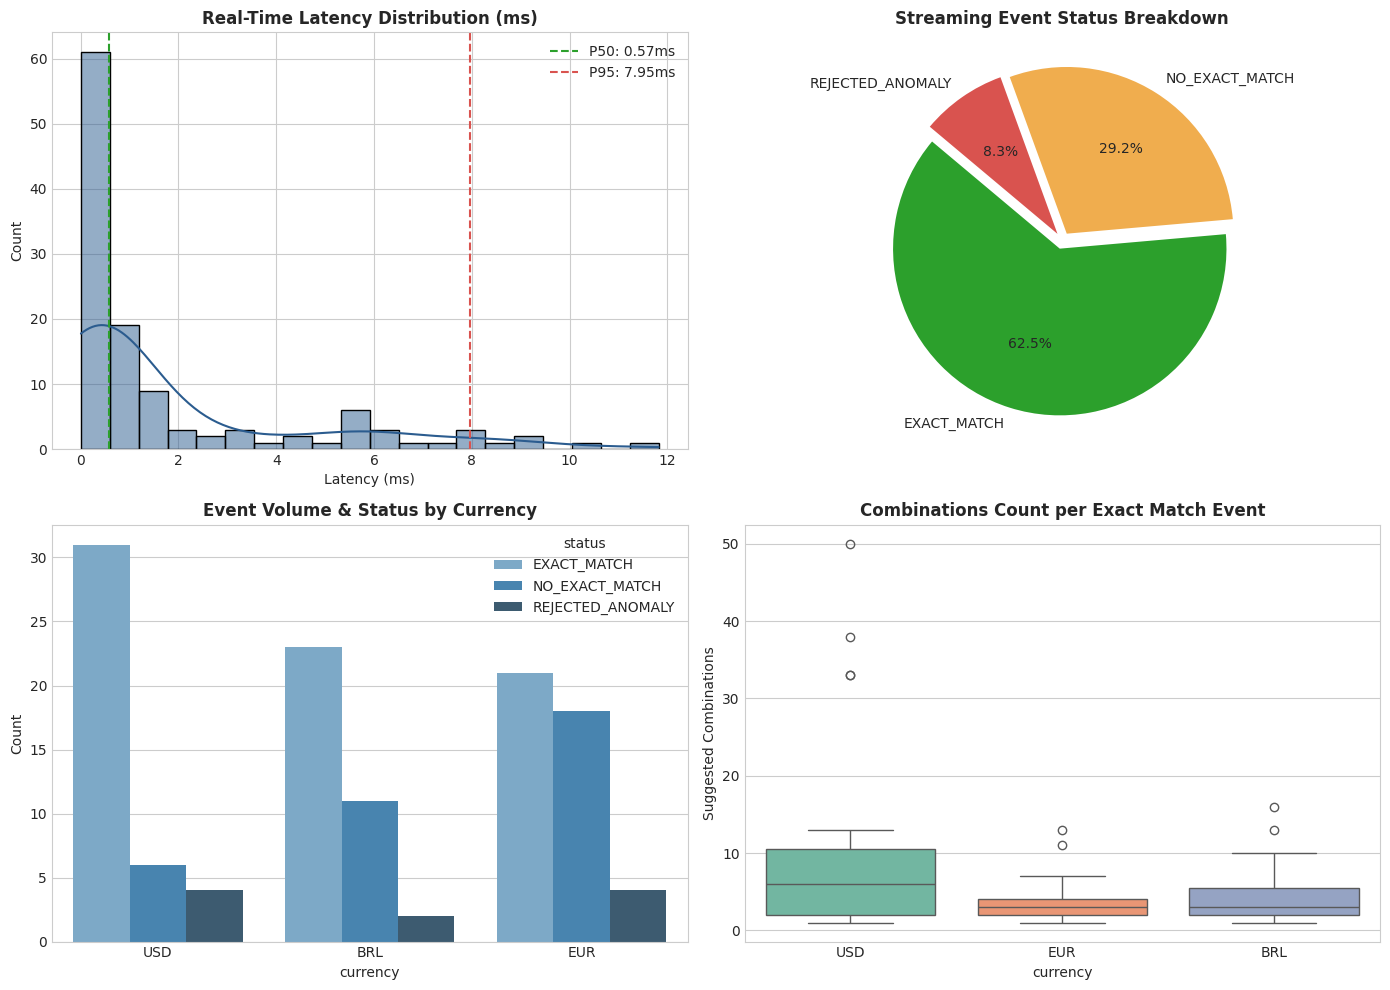

In [10]:
# Visual Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Latency Distribution
sns.histplot(df_telemetry["latency_ms"], kde=True, ax=axes[0, 0], color="#2b5c8f", bins=20)
axes[0, 0].axvline(p50, color="#2ca02c", linestyle="--", label=f"P50: {p50:.2f}ms")
axes[0, 0].axvline(p95, color="#d9534f", linestyle="--", label=f"P95: {p95:.2f}ms")
axes[0, 0].set_title("Real-Time Latency Distribution (ms)", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Latency (ms)")
axes[0, 0].legend()

# 2. Event Status Distribution
status_counts = df_telemetry["status"].value_counts()
colors = ["#2ca02c", "#f0ad4e", "#d9534f"]
axes[0, 1].pie(
    status_counts,
    labels=status_counts.index,
    autopct="%1.1f%%",
    colors=colors[:len(status_counts)],
    startangle=140,
    explode=[0.05] * len(status_counts)
)
axes[0, 1].set_title("Streaming Event Status Breakdown", fontsize=12, fontweight="bold")

# 3. Currency Distribution vs Status
sns.countplot(data=df_telemetry, x="currency", hue="status", ax=axes[1, 0], palette="Blues_d")
axes[1, 0].set_title("Event Volume & Status by Currency", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("Count")

# 4. Combinations Count per Event
sns.boxplot(data=df_telemetry[df_telemetry["combinations_count"] > 0], x="currency", y="combinations_count", hue="currency", ax=axes[1, 1], palette="Set2", legend=False)
axes[1, 1].set_title("Combinations Count per Exact Match Event", fontsize=12, fontweight="bold")
axes[1, 1].set_ylabel("Suggested Combinations")

plt.tight_layout()
plt.show()


---
### 11 - Anomaly Firewall & Stress Testing Benchmark (500 Events)

Evaluating the engine under a 500-event continuous workload with intentionally corrupted payloads to confirm zero false positives and guaranteed financial isolation.


In [11]:
stress_stream = generate_stream_events(n_events=500, anomaly_ratio=0.25, seed=777)
stress_validator = RealtimeAInvoiceValidator(
    model=pytorch_model,
    payment_history=payment_history,
    solver_name="branch_and_bound",
    max_combinations=50
)

start_stress = time.time()
for evt in stress_stream:
    stress_validator.process_event(evt)
total_stress_time = time.time() - start_stress

df_stress = stress_validator.get_telemetry_dataframe()

print(f"=== STRESS TEST RESULTS ({len(stress_stream)} EVENTS) ===")
print(f"Total Wall Clock Time: {total_stress_time:.2f} seconds")
print(f"Average Throughput: {len(stress_stream) / total_stress_time:.1f} events/sec")
print(f"Mean Event Latency: {df_stress['latency_ms'].mean():.2f} ms")
print(f"P95 Latency: {np.percentile(df_stress['latency_ms'], 95):.2f} ms")
print(f"P99 Latency: {np.percentile(df_stress['latency_ms'], 99):.2f} ms")

anom_summary = df_stress["anomaly_type"].value_counts().reset_index()
anom_summary.columns = ["Anomaly Detected", "Count"]
display(anom_summary)


=== STRESS TEST RESULTS (500 EVENTS) ===
Total Wall Clock Time: 0.99 seconds
Average Throughput: 502.8 events/sec
Mean Event Latency: 1.97 ms
P95 Latency: 8.64 ms
P99 Latency: 18.94 ms


,Anomaly Detected,Count
0,NONE,368
1,DUPLICATE_INVOICE_ID,40
2,STATUS_NOT_OPEN,31
3,CUSTOMER_MISMATCH,31
4,INVALID_VALUE,30


---
### 12 - Conclusion & External System Integration

#### External Integration Cheat-Sheet:
To integrate the pure deterministic mathematical engine into external systems (FastAPI, ERP, Microservices):

```python
from src.pipeline import find_deterministic_matches

# Call directly with your JSON payload
result = find_deterministic_matches(
    amount=5000.00,
    invoices=invoices_list,
    currency="USD",
    exchange_rate=5.00,
    ranking_strategy="fewest_invoices"
)
print(result["status"])  # 'EXACT_MATCH'
print(result["combinations"])  # List of exact audited matches
```

All calculations are guaranteed exact in integer cents ($0.00$ residual balance).
